In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_ravenstack_subscriptions.csv")

In [3]:
print(df.head())

  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0      True          True           False       False   
3         995       11940     False         False           False        True   
4        5373       64476     False         False           False       False   

  billing_frequency  auto_renew_flag cohortMonth SubscriptionM

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
 14  cohortMonth        5000 non-null   str  
 15  SubscriptionMonth  5000 non-null   str  
dtypes: bool(5), int64(3), str(8)
memory usage: 454.2 KB
None


In [5]:
df['start_date'] = pd.to_datetime(df['start_date'])

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   str           
 1   account_id         5000 non-null   str           
 2   start_date         5000 non-null   datetime64[us]
 3   end_date           486 non-null    str           
 4   plan_tier          5000 non-null   str           
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   str           
 13  auto_renew_flag    5000 non-null   bool          
 14  cohortMonth        

In [7]:
df['ActivityMonth'] = df['start_date'].dt.to_period('M')

In [8]:
print(df[['start_date', 'ActivityMonth']].head())

  start_date ActivityMonth
0 2023-12-23       2023-12
1 2024-06-11       2024-06
2 2024-11-25       2024-11
3 2024-11-23       2024-11
4 2024-01-10       2024-01


In [9]:
df['CohortMonth'] = df.groupby('account_id')['ActivityMonth'].transform('min')

In [10]:
print(df[['account_id', 'ActivityMonth', 'CohortMonth']].head(10))

  account_id ActivityMonth CohortMonth
0   A-3c1a3f       2023-12     2023-08
1   A-9b9fe9       2024-06     2023-10
2   A-659280       2024-11     2023-11
3   A-e7a1e2       2024-11     2024-07
4   A-ba6516       2024-01     2024-01
5   A-fa2041       2024-08     2024-06
6   A-417d2f       2023-12     2023-07
7   A-5f2961       2024-12     2024-11
8   A-cc8c8f       2024-11     2024-06
9   A-80eeb6       2024-10     2023-07


In [11]:
activity_year = df['ActivityMonth'].dt.year
activity_month = df['ActivityMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

In [13]:
df['CohortIndex'] = (
    (activity_year - cohort_year) * 12
    + (activity_month - cohort_month)
)

In [14]:
print(df[['account_id', 'ActivityMonth', 'CohortMonth', 'CohortIndex']].head(10))

  account_id ActivityMonth CohortMonth  CohortIndex
0   A-3c1a3f       2023-12     2023-08            4
1   A-9b9fe9       2024-06     2023-10            8
2   A-659280       2024-11     2023-11           12
3   A-e7a1e2       2024-11     2024-07            4
4   A-ba6516       2024-01     2024-01            0
5   A-fa2041       2024-08     2024-06            2
6   A-417d2f       2023-12     2023-07            5
7   A-5f2961       2024-12     2024-11            1
8   A-cc8c8f       2024-11     2024-06            5
9   A-80eeb6       2024-10     2023-07           15


In [15]:
grouping = df.groupby(['CohortMonth', 'CohortIndex'])['account_id'].nunique()

In [16]:
cohort_data = grouping.reset_index()

In [17]:
print(cohort_data.head(10))

  CohortMonth  CohortIndex  account_id
0     2023-01            0           2
1     2023-01            1           1
2     2023-01            2           1
3     2023-01            3           1
4     2023-01            6           2
5     2023-01            9           1
6     2023-01           10           1
7     2023-01           16           1
8     2023-01           18           1
9     2023-01           20           2


In [18]:
cohort_counts = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='account_id'
)

In [19]:
print(cohort_counts.head())

CohortIndex    0    1    2    3    4    5    6    7    8    9   ...   13   14  \
CohortMonth                                                     ...             
2023-01       2.0  1.0  1.0  1.0  NaN  NaN  2.0  NaN  NaN  1.0  ...  NaN  NaN   
2023-02       8.0  4.0  4.0  3.0  4.0  2.0  3.0  3.0  5.0  2.0  ...  5.0  4.0   
2023-03      11.0  5.0  4.0  2.0  4.0  2.0  1.0  6.0  4.0  4.0  ...  2.0  6.0   
2023-04      15.0  5.0  4.0  7.0  4.0  5.0  5.0  3.0  5.0  4.0  ...  7.0  6.0   
2023-05      14.0  5.0  7.0  9.0  5.0  4.0  4.0  3.0  5.0  7.0  ...  5.0  7.0   

CohortIndex   15   16   17    18   19   20   21   22  
CohortMonth                                           
2023-01      NaN  1.0  NaN   1.0  NaN  2.0  1.0  NaN  
2023-02      3.0  NaN  4.0   3.0  2.0  2.0  4.0  3.0  
2023-03      6.0  2.0  4.0   6.0  5.0  3.0  6.0  NaN  
2023-04      4.0  3.0  8.0  10.0  7.0  5.0  NaN  NaN  
2023-05      6.0  6.0  5.0   4.0  5.0  NaN  NaN  NaN  

[5 rows x 23 columns]


In [20]:
cohort_size = cohort_counts.iloc[:, 0]

In [21]:
retention_matrix = cohort_counts.divide(cohort_size, axis=0)

In [22]:
retention_matrix = retention_matrix.round(3) * 100

In [23]:
print(retention_matrix.head())

CohortIndex     0     1     2     3     4     5      6     7     8     9   \
CohortMonth                                                                 
2023-01      100.0  50.0  50.0  50.0   NaN   NaN  100.0   NaN   NaN  50.0   
2023-02      100.0  50.0  50.0  37.5  50.0  25.0   37.5  37.5  62.5  25.0   
2023-03      100.0  45.5  36.4  18.2  36.4  18.2    9.1  54.5  36.4  36.4   
2023-04      100.0  33.3  26.7  46.7  26.7  33.3   33.3  20.0  33.3  26.7   
2023-05      100.0  35.7  50.0  64.3  35.7  28.6   28.6  21.4  35.7  50.0   

CohortIndex  ...    13    14    15    16    17    18    19     20    21    22  
CohortMonth  ...                                                               
2023-01      ...   NaN   NaN   NaN  50.0   NaN  50.0   NaN  100.0  50.0   NaN  
2023-02      ...  62.5  50.0  37.5   NaN  50.0  37.5  25.0   25.0  50.0  37.5  
2023-03      ...  18.2  54.5  54.5  18.2  36.4  54.5  45.5   27.3  54.5   NaN  
2023-04      ...  46.7  40.0  26.7  20.0  53.3  66.7  46.7  

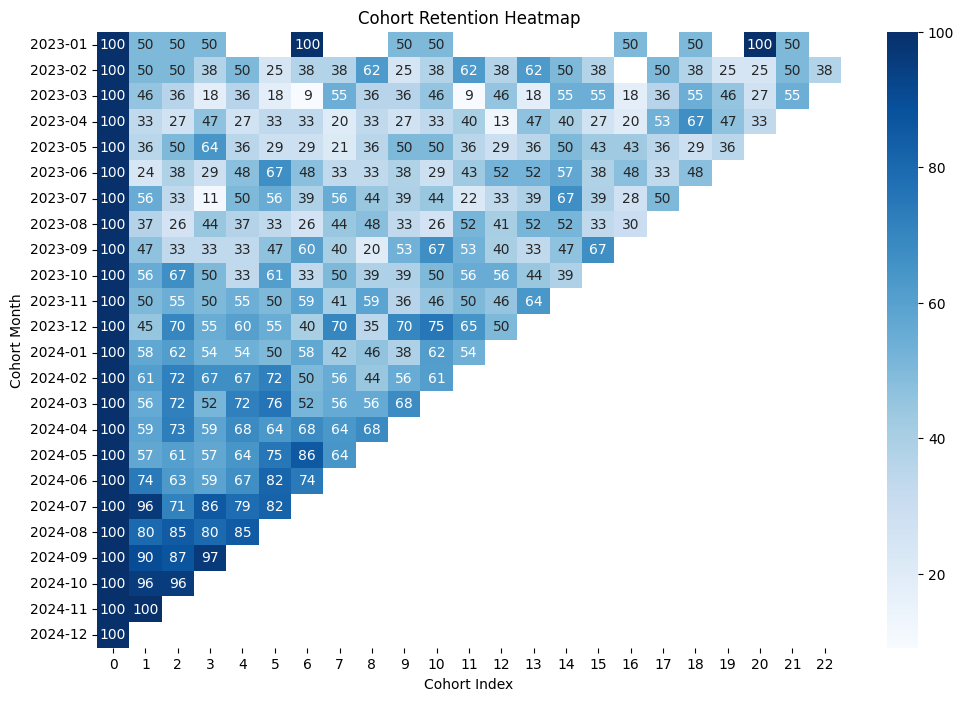

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Cohort Retention Heatmap')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')

plt.show()

In [25]:
retention_matrix.to_csv("cohort_retention_matrix.csv")

In [26]:
plt.savefig("cohort_retention_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [27]:
print("Cohort analysis completed successfully")

Cohort analysis completed successfully


In [28]:
df.to_csv("processed_cohort_data.csv", index=False)

In [29]:
print(retention_matrix.describe())

CohortIndex     0           1          2          3          4          5   \
count         24.0   23.000000  22.000000  21.000000  19.000000  18.000000   
mean         100.0   58.943478  58.009091  52.361905  53.673684  54.105556   
std            0.0   21.123099  19.942439  20.559559  16.937166  20.028494   
min          100.0   23.800000  25.900000  11.100000  26.700000  18.200000   
25%          100.0   46.100000  41.075000  44.400000  36.700000  36.650000   
50%          100.0   55.600000  61.100000  52.000000  53.800000  55.300000   
75%          100.0   67.600000  71.850000  59.300000  66.700000  70.825000   
max          100.0  100.000000  95.700000  96.800000  85.000000  82.100000   

CohortIndex          6          7          8          9   ...        13  \
count         18.000000  16.000000  15.000000  15.000000  ...  10.00000   
mean          50.055556  46.837500  44.100000  43.940000  ...  44.76000   
std           22.475038  14.548671  12.984496  13.502317  ...  13.88878 

In [30]:
retention_matrix.mean(axis=1)

CohortMonth
2023-01     63.636364
2023-02     44.886364
2023-03     38.854545
2023-04     38.095238
2023-05     41.790000
2023-06     45.110526
2023-07     44.755556
2023-08     42.029412
2023-09     48.331250
2023-10     51.486667
2023-11     54.221429
2023-12     60.769231
2024-01     56.400000
2024-02     64.145455
2024-03     66.000000
2024-04     69.188889
2024-05     70.525000
2024-06     74.100000
2024-07     85.700000
2024-08     86.000000
2024-09     93.550000
2024-10     97.133333
2024-11    100.000000
2024-12    100.000000
Freq: M, dtype: float64

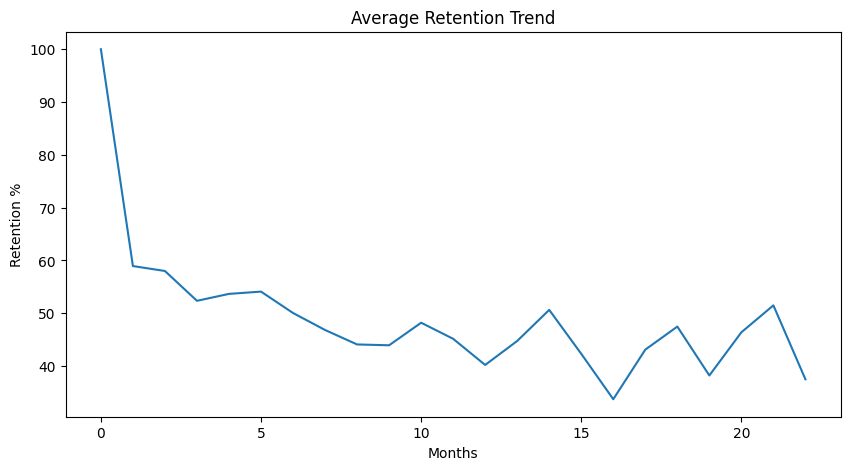

In [31]:
retention_matrix.mean().plot(figsize=(10,5))
plt.title("Average Retention Trend")
plt.xlabel("Months")
plt.ylabel("Retention %")
plt.show()

In [32]:
top_cohorts = retention_matrix.mean(axis=1).sort_values(ascending=False)

print(top_cohorts.head())

CohortMonth
2024-11    100.000000
2024-12    100.000000
2024-10     97.133333
2024-09     93.550000
2024-08     86.000000
Freq: M, dtype: float64


In [33]:
monthly_retention = retention_matrix.mean()

print(monthly_retention)

CohortIndex
0     100.000000
1      58.943478
2      58.009091
3      52.361905
4      53.673684
5      54.105556
6      50.055556
7      46.837500
8      44.100000
9      43.940000
10     48.214286
11     45.166667
12     40.218182
13     44.760000
14     50.644444
15     42.325000
16     33.728571
17     43.116667
18     47.483333
19     38.225000
20     46.400000
21     51.500000
22     37.500000
dtype: float64


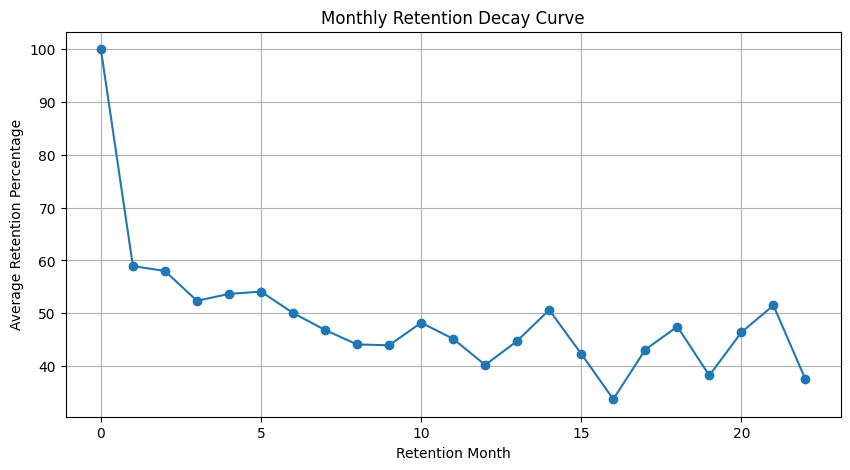

In [34]:
monthly_retention.plot(marker='o', figsize=(10,5))

plt.title("Monthly Retention Decay Curve")
plt.xlabel("Retention Month")
plt.ylabel("Average Retention Percentage")

plt.grid(True)
plt.show()

In [35]:
retention_matrix.to_excel("cohort_retention_analysis.xlsx")

ModuleNotFoundError: No module named 'openpyxl'

In [36]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [37]:
retention_matrix.to_excel("cohort_retention_analysis.xlsx")

In [38]:
print("Files exported successfully")

Files exported successfully


In [39]:
retention_matrix.shape

(24, 23)

In [40]:
retention_matrix.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22],
      dtype='int64', name='CohortIndex')

In [41]:
retention_matrix.index

PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06',
             '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12',
             '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06',
             '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12'],
            dtype='period[M]', name='CohortMonth')

In [42]:
retention_matrix.iloc[:5, :5]

CohortIndex,0,1,2,3,4
CohortMonth,,,,,
2023-01,100.0,50.0,50.0,50.0,NaN
2023-02,100.0,50.0,50.0,37.5,50.0
2023-03,100.0,45.5,36.4,18.2,36.4
2023-04,100.0,33.3,26.7,46.7,26.7
2023-05,100.0,35.7,50.0,64.3,35.7


In [43]:
retention_matrix.fillna(0, inplace=True)

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2023-01,100.0,50.0,50.0,50.0,0.0,0.0,100.0,0.0,0.0,50.0,...,0.0,0.0,0.0,50.0,0.0,50.0,0.0,100.0,50.0,0.0
2023-02,100.0,50.0,50.0,37.5,50.0,25.0,37.5,37.5,62.5,25.0,...,62.5,50.0,37.5,0.0,50.0,37.5,25.0,25.0,50.0,37.5
2023-03,100.0,45.5,36.4,18.2,36.4,18.2,9.1,54.5,36.4,36.4,...,18.2,54.5,54.5,18.2,36.4,54.5,45.5,27.3,54.5,0.0
2023-04,100.0,33.3,26.7,46.7,26.7,33.3,33.3,20.0,33.3,26.7,...,46.7,40.0,26.7,20.0,53.3,66.7,46.7,33.3,0.0,0.0
2023-05,100.0,35.7,50.0,64.3,35.7,28.6,28.6,21.4,35.7,50.0,...,35.7,50.0,42.9,42.9,35.7,28.6,35.7,0.0,0.0,0.0
2023-06,100.0,23.8,38.1,28.6,47.6,66.7,47.6,33.3,33.3,38.1,...,52.4,57.1,38.1,47.6,33.3,47.6,0.0,0.0,0.0,0.0
2023-07,100.0,55.6,33.3,11.1,50.0,55.6,38.9,55.6,44.4,38.9,...,38.9,66.7,38.9,27.8,50.0,0.0,0.0,0.0,0.0,0.0
2023-08,100.0,37.0,25.9,44.4,37.0,33.3,25.9,44.4,48.1,33.3,...,51.9,51.9,33.3,29.6,0.0,0.0,0.0,0.0,0.0,0.0
2023-09,100.0,46.7,33.3,33.3,33.3,46.7,60.0,40.0,20.0,53.3,...,33.3,46.7,66.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
retention_matrix.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2023-01,100.0,50.0,50.0,50.0,0.0,0.0,100.0,0.0,0.0,50.0,...,0.0,0.0,0.0,50.0,0.0,50.0,0.0,100.0,50.0,0.0
2023-02,100.0,50.0,50.0,37.5,50.0,25.0,37.5,37.5,62.5,25.0,...,62.5,50.0,37.5,0.0,50.0,37.5,25.0,25.0,50.0,37.5
2023-03,100.0,45.5,36.4,18.2,36.4,18.2,9.1,54.5,36.4,36.4,...,18.2,54.5,54.5,18.2,36.4,54.5,45.5,27.3,54.5,0.0
2023-04,100.0,33.3,26.7,46.7,26.7,33.3,33.3,20.0,33.3,26.7,...,46.7,40.0,26.7,20.0,53.3,66.7,46.7,33.3,0.0,0.0
2023-05,100.0,35.7,50.0,64.3,35.7,28.6,28.6,21.4,35.7,50.0,...,35.7,50.0,42.9,42.9,35.7,28.6,35.7,0.0,0.0,0.0


In [45]:
cohort_counts.to_csv("cohort_counts.csv")

In [46]:
monthly_retention.to_csv("monthly_retention.csv")

In [47]:
top_cohorts.to_csv("top_cohorts.csv")

In [48]:
print(df.columns)

Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag',
       'cohortMonth', 'SubscriptionMonth', 'ActivityMonth', 'CohortMonth',
       'CohortIndex'],
      dtype='str')


In [49]:
df[['account_id', 'plan_tier', 'mrr_amount', 'churn_flag']].head()

,account_id,plan_tier,mrr_amount,churn_flag
0,A-3c1a3f,Enterprise,2786,True
1,A-9b9fe9,Pro,833,False
2,A-659280,Enterprise,0,False
3,A-e7a1e2,Enterprise,995,True
4,A-ba6516,Enterprise,5373,False


In [50]:
df.groupby('plan_tier')['mrr_amount'].mean()

plan_tier
Basic          474.679775
Enterprise    4917.713871
Pro           1256.769552
Name: mrr_amount, dtype: float64

In [51]:
df.groupby('plan_tier')['churn_flag'].mean() * 100

plan_tier
Basic         9.488140
Enterprise    9.982589
Pro           9.671642
Name: churn_flag, dtype: float64

In [66]:
df.groupby('plan_tier')['mrr_amount'].sum()

plan_tier
Basic          760437
Enterprise    8473221
Pro           2105089
Name: mrr_amount, dtype: int64

In [67]:
df.groupby('plan_tier')['subscription_id'].count()

plan_tier
Basic         1602
Enterprise    1723
Pro           1675
Name: subscription_id, dtype: int64

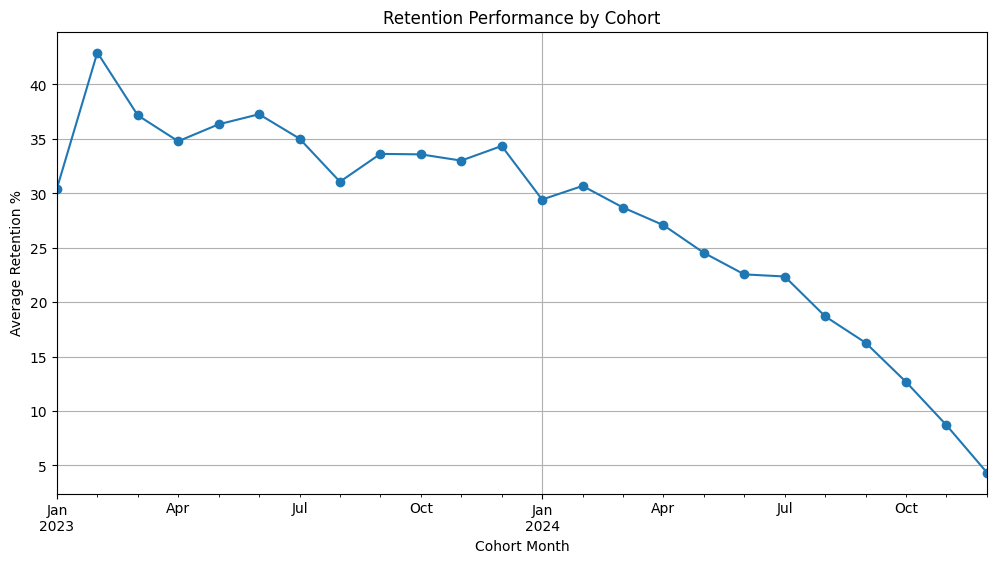

In [68]:
retention_matrix.mean(axis=1).plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Retention Performance by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Average Retention %")

plt.grid(True)

plt.show()

In [69]:
churn_rate = df.groupby('plan_tier')['churn_flag'].mean() * 100

print(churn_rate)

plan_tier
Basic         9.488140
Enterprise    9.982589
Pro           9.671642
Name: churn_flag, dtype: float64


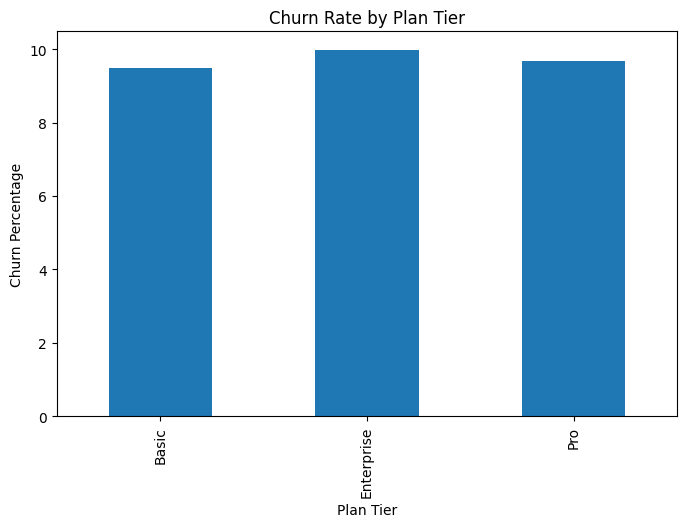

In [70]:
churn_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Churn Percentage")

plt.show()

In [71]:
final_summary = {
    "Total Customers": df['account_id'].nunique(),
    "Total Subscriptions": df['subscription_id'].nunique(),
    "Average CLTV": cltv_data['CLTV'].mean(),
    "Highest CLTV": cltv_data['CLTV'].max()
}

print(final_summary)

{'Total Customers': 500, 'Total Subscriptions': 5000, 'Average CLTV': np.float64(22677.494), 'Highest CLTV': np.float64(138060.0)}


In [72]:
pd.DataFrame([final_summary]).to_csv(
    "business_summary.csv",
    index=False
)

In [73]:
with open("business_insights.txt", "w") as file:
    file.write("Cohort Retention & CLTV Analysis Summary\n\n")
    
    file.write(f"Total Customers: {df['account_id'].nunique()}\n")
    file.write(f"Total Subscriptions: {df['subscription_id'].nunique()}\n")
    file.write(f"Average CLTV: {cltv_data['CLTV'].mean()}\n")
    file.write(f"Highest CLTV: {cltv_data['CLTV'].max()}\n\n")
    
    file.write("Key Insights:\n")
    file.write("- Retention decreases over time across cohorts.\n")
    file.write("- Some plan tiers generate higher CLTV.\n")
    file.write("- Early churn impacts long-term retention.\n")
    file.write("- High-value customers contribute significantly to revenue.\n")

In [74]:
print("Business insights exported successfully")

Business insights exported successfully


In [75]:
import os

project_files = os.listdir()

print(project_files)

['.git', '.ipynb_checkpoints', 'business_insights.txt', 'business_summary.csv', 'cleaned_ravenstack_subscriptions.csv', 'cltv_summary.csv', 'cohort_analysis.ipynb', 'cohort_analysis_methodology.md', 'cohort_counts.csv', 'cohort_retention_analysis.xlsx', 'cohort_retention_heatmap.png', 'cohort_retention_matrix.csv', 'customer_cltv_analysis.csv', 'dataset_overview.md', 'high_value_customers.csv', 'monthly_retention.csv', 'processed_cohort_data.csv', 'README.md', 'README_backup.md', 'top_cohorts.csv', 'week1_data_cleaning.md', 'week2_documentation.md']


In [78]:
print("Week 2 analysis completed successfully")

Week 2 analysis completed successfully
